In [28]:
import fitness_landscape as fl
import os
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
import networkx as nx
from tqdm import tqdm
import matplotlib.pyplot as plt

### DMS and Megascale folding dataset

In [2]:
# Prepare file list
file_list = os.listdir('../data_files/protein_gym/DMS_assays_substitutions')
file_list = [file for file in file_list if file != '.DS_Store']
file_list.sort()

# Initialise empty results list
results = []

for _, file in tqdm(enumerate(file_list)):
    df = pd.read_csv(os.path.join('../data_files/protein_gym/DMS_assays_substitutions/', file))

    # Skip large datasets
    if len(df) > 4000:
        continue

    # Extract sequence objects
    sequences = [fl.BaseNumpySequence(sequence) for sequence in df['mutated_sequence']]
    fitness = np.array(df['DMS_score'])

    rep_out = {
        "file": str(file),
        "n_sequences": len(sequences)}

    # Construct fitness landscape with Hamming graph for DMS data
    landscape = fl.FitnessLandscape.build(
        sequences,
        graph="hamming",
    )

    # Check if there is more than a single connected component and skip if so
    G = landscape.graph  # nx.Graph
    if not nx.is_connected(G):
        continue

    # Attach fitness values
    layer_name = f"dms_score"
    landscape.attach(name=layer_name, values=fitness, dtype="numeric")
    landscape.view(layer_name)

    # Compute tmap results
    tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(landscape, t_min=1e-10, t_max=1e2, prior='uniform')

    # Collect results
    rep_out["tmap"] =  tmap_res
    results.append(rep_out)

210it [1:04:54, 18.55s/it]


ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 2


In [3]:
results

[{'file': 'A0A1I9GEU1_NEIME_Kennouche_2019.csv',
  'n_sequences': 922,
  'tmap': {'t_map': 1e-10,
   't_lower_confidence_interval': 0.03858725671785391,
   't_upper_confidence_interval': 3.5445262103124917,
   't_logposterior_map': -1706.1996495320304,
   'variance_approximate': 1.0184696016888084}},
 {'file': 'A0A247D711_LISMN_Stadelmann_2021.csv',
  'n_sequences': 1653,
  'tmap': {'t_map': 1e-10,
   't_lower_confidence_interval': 0.012406854963306745,
   't_upper_confidence_interval': 1.580383801637425,
   't_logposterior_map': -2780.2325144796832,
   'variance_approximate': 0.19054992673058196}},
 {'file': 'A0A2Z5U3Z0_9INFA_Wu_2014.csv',
  'n_sequences': 2350,
  'tmap': {'t_map': 1e-10,
   't_lower_confidence_interval': 0.03539675738498153,
   't_upper_confidence_interval': 3.733727284275238,
   't_logposterior_map': -3305.83758590855,
   'variance_approximate': 1.0988063695006107}},
 {'file': 'AACC1_PSEAI_Dandage_2018.csv',
  'n_sequences': 1801,
  'tmap': {'t_map': 1e-10,
   't_lo

In [4]:
out_pkl = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.pkl")
out_json = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.json")

def _jsonable(obj):
    import numpy as np

    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(x) for x in obj]
    return obj

# Save pickle
with open(out_pkl, "wb") as f:
    pickle.dump(results, f)

# Save json
with open(out_json, "w") as f:
    json.dump(_jsonable(results), f, indent=2)


In [5]:
# Reload results
out_pkl = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.pkl")

with open(out_pkl, "rb") as f:
    results = pickle.load(f)

Dropping rows where t is outside [t_lo, t_hi]:
        dataset             t      t_lo      t_hi
0    AMFR-HUMAN  1.000000e-10  0.001390  0.165536
1    BBC1-YEAST  1.000000e-10  0.001346  0.190704
3   CAR11-HUMAN  1.000000e-10  0.001346  0.192274
4   CASP7-HUMAN  1.000000e-10  0.004426  0.626414
6   CBPA2-HUMAN  1.000000e-10  0.000273  0.039470
12    DYR-ECOLI  1.000000e-10  0.002691  0.378890
13    DYR-ECOLI  1.000000e-10  0.002350  0.333415
14  EPHB2-HUMAN  1.000000e-10  0.001526  0.183802
15   FECA-ECOLI  1.000000e-10  0.001961  0.275463
16   GCN4-YEAST  1.000000e-10  0.004777  0.626149
18    IF1-ECOLI  1.000000e-10  0.008169  0.925366
19   ILF3-HUMAN  1.000000e-10  0.001876  0.257491
20   ISDH-STAAW  1.000000e-10  0.003285  0.386346
21  KCNE1-HUMAN  1.000000e-10  0.000761  0.109372
34   PSAE-SYNP2  1.000000e-10  0.001104  0.147166
35   RASH-HUMAN  1.000000e-10  0.002705  0.382279
41   RL20-AQUAE  7.068302e+00  6.362243  7.050505
42  RL40A-YEAST  1.000000e-10  0.002905  0.392948
43 

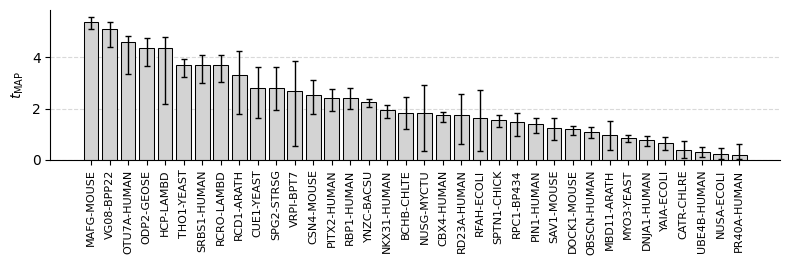

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Build dataframe
# -----------------------------
rows = []
for r in results:
    fname = r["file"].replace(".csv", "")
    dataset = "-".join(fname.split("_")[0:2])

    rows.append({
        "dataset": dataset,
        "t": r["tmap"]["t_map"],
        "t_lo": r["tmap"]["t_lower_confidence_interval"],
        "t_hi": r["tmap"]["t_upper_confidence_interval"],
    })

df = pd.DataFrame(rows)

# Coerce numeric + drop non-finite
for c in ["t", "t_lo", "t_hi"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["t", "t_lo", "t_hi"]).reset_index(drop=True)

# -----------------------------
# Fix CI ordering (ensure lo <= hi)
# -----------------------------
lo = np.minimum(df["t_lo"].to_numpy(), df["t_hi"].to_numpy())
hi = np.maximum(df["t_lo"].to_numpy(), df["t_hi"].to_numpy())
df["t_lo"] = lo
df["t_hi"] = hi

# -----------------------------
# Drop poorly fitted datasets (avoid div-by-zero)
# -----------------------------
eps = 1e-300  # tiny, only to avoid division by zero
poor_fit = ((df["t_hi"] / np.maximum(df["t_lo"], eps)) >= 10.0) & (df["t_hi"] > 1.0)
df = df.loc[~poor_fit].reset_index(drop=True)

# -----------------------------
# Ensure t is inside [lo, hi]
# If not, you can either DROP or CLAMP. Dropping is safer/cleaner.
# -----------------------------
bad = (df["t"] < df["t_lo"]) | (df["t"] > df["t_hi"])
if bad.any():
    print("Dropping rows where t is outside [t_lo, t_hi]:")
    print(df.loc[bad, ["dataset", "t", "t_lo", "t_hi"]])
df = df.loc[~bad].reset_index(drop=True)

# -----------------------------
# Sort by t descending
# -----------------------------
df = df.sort_values("t", ascending=False).reset_index(drop=True)

# -----------------------------
# Asymmetric error bars (guaranteed non-negative now)
# -----------------------------
t = df["t"].to_numpy()
t_lo = df["t_lo"].to_numpy()
t_hi = df["t_hi"].to_numpy()
yerr = np.vstack([t - t_lo, t_hi - t])

# -----------------------------
# Plot (single bar call; x aligned with errorbar)
# -----------------------------
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(8, 2.75))

ax.bar(
    x,
    t,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.75,
    zorder=2
)

ax.errorbar(
    x=x,
    y=t,
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=2,
    zorder=3
)

step = 1  # change to 3 if you truly want every 3rd label
ax.set_xticks(x[::step])
ax.set_xticklabels(df["dataset"].iloc[::step], rotation=90, fontsize=8)

ax.set_ylabel(r"$t_{\mathrm{MAP}}$")
# ax.set_yscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", ls="--", c="0.85", zorder=1)

plt.tight_layout()
plt.savefig("../figures/figure_2/tmap_vs_dms.pdf")
plt.show()

### Rugged example
PR40A_HUMAN_Tsuboyama_2023_1UZC.csv

In [96]:
df = pd.read_csv('../data_files/megascale_folding/PR40A_HUMAN_Tsuboyama_2023_1UZC.csv')

sequences = [fl.BaseNumpySequence(sequence) for sequence in df['mutated_sequence']]
fitness = np.array(df['DMS_score'])

# Construct fitness landscape with Hamming graph for DMS data
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="hamming",
)


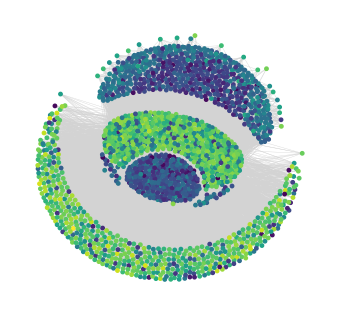

In [105]:
G = landscape.graph

edge_frac = 0.01
seed = 0  # for reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# Use a fixed layout so nodes/edges align
# (spring_layout can be slow for large graphs; if G already has positions, use those)
pos = nx.spring_layout(G, seed=seed, k=0.0005)

fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Draw only sampled edges
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# Draw all nodes
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=6,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()

plt.tight_layout()
# plt.savefig('../figures/figure_2/DNJA1_HUMAN_Tsuboyama_2023_2LO1_rugged_example.pdf')
plt.show()

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ------------------------------------------------------------
# Graph + edge subsampling
# ------------------------------------------------------------
G = landscape.graph

edge_frac = 0.01
seed = 0  # reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# ------------------------------------------------------------
# Graphviz SFDP layout (preferred)
# Requires Graphviz installed + pygraphviz OR pydot
# ------------------------------------------------------------
pos = None
layout_errs = []

# Try pygraphviz backend first (usually best)
try:
    from networkx.drawing.nx_agraph import graphviz_layout
    pos = graphviz_layout(G, prog="sfdp")
except Exception as e:
    layout_errs.append(f"pygraphviz backend failed: {e}")

# Fallback to pydot backend
if pos is None:
    try:
        from networkx.drawing.nx_pydot import graphviz_layout
        pos = graphviz_layout(G, prog="sfdp")
    except Exception as e:
        layout_errs.append(f"pydot backend failed: {e}")

# Final fallback (so the cell still runs)
if pos is None:
    print("Could not use Graphviz sfdp layout. Falling back to spring_layout.")
    for msg in layout_errs:
        print(" -", msg)
    pos = nx.spring_layout(G, seed=seed, k=0.0005)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Sampled edges only
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# All nodes
nodes = nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=6,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()
plt.tight_layout()

# Optional save
# plt.savefig(
#     "../figures/figure_2/DNJA1_HUMAN_Tsuboyama_2023_2LO1_rugged_example.pdf",
#     bbox_inches="tight"
# )

plt.show()

Python(46168) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


KeyboardInterrupt: 

### Smooth example 
MAFG_MOUSE_Tsuboyama_2023_1K1V.csv

In [86]:
df = pd.read_csv('../data_files/megascale_folding/OTU7A_HUMAN_Tsuboyama_2023_2L2D.csv')

sequences = [fl.BaseNumpySequence(sequence) for sequence in df['mutated_sequence']]
fitness = np.array(df['DMS_score'])

# Construct fitness landscape with Hamming graph for DMS data
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="hamming",
)

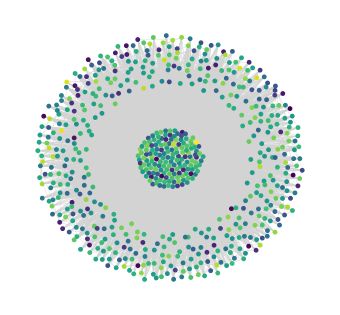

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

G = landscape.graph

edge_frac = 0.10
seed = 0  # for reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# Use a fixed layout so nodes/edges align
# (spring_layout can be slow for large graphs; if G already has positions, use those)
pos = nx.spring_layout(G, seed=seed)

fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Draw only sampled edges
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# Draw all nodes
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=6,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()
plt.tight_layout()
# plt.savefig(
#     "../figures/figure_2/MAFG_MOUSE_Tsuboyama_2023_1K1V_smooth_example.pdf",
#     bbox_inches="tight"
# )
plt.show()

## Sparse datasets

In [22]:
# Prepare file list
file_list = os.listdir('../data_files/sparse_datasets')
file_list = [file for file in file_list if file != '.DS_Store']
file_list.sort()

# Initialise empty results list
results = []

for _, file in tqdm(enumerate(file_list)):
    df = pd.read_csv(os.path.join('../data_files/sparse_datasets/', file))
    df = df.dropna()

    # if len(df) > 4000:
    #     continue

    # Extract sequence objects
    seqs_raw = df["sequence"].astype(str).str.strip().str.replace(".", "-", regex=False)

    L = seqs_raw.str.len().max()  # target alignment length
    seqs_raw = seqs_raw.str.pad(width=L, side="right", fillchar="-")

    sequences = [fl.BaseNumpySequence(s) for s in seqs_raw]
    fitness = df["fitness"].to_numpy()

    # Scale K to sqrt of number of sequences
    knn_k = max(int(np.sqrt(len(sequences))), 2)

    rep_out = {
        "file": str(file),
        "n_sequences": len(sequences),
        "knn_k": knn_k}

    # Construct fitness landscape
    landscape = fl.FitnessLandscape.build(
        sequences,
        graph="knn",
        k=knn_k,
        backend="auto",
        _compute_hamming_edges=False
    )

    
    # Attach fitness values
    layer_name = f"fitness"
    landscape.attach(name=layer_name, values=fitness, dtype="numeric")
    landscape.view(layer_name)

    # Check if there is more than a single connected component and proceed on the largest connected component if so
    G = landscape.graph  # nx.Graph
    if not nx.is_connected(G):

        landscape = landscape.get_components()[0]
        continue

    # Compute tmap results
    tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(landscape, t_min=1e-10, t_max=1e2, prior='uniform')

    # Collect results
    rep_out["tmap"] =  tmap_res
    results.append(rep_out)

1it [00:02,  2.30s/it]/Users/matthewspence/Documents/Documents/graph-ruggedness-de/.env/lib/python3.12/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 39 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "
2it [00:03,  1.70s/it]/Users/matthewspence/Documents/Documents/graph-ruggedness-de/.env/lib/python3.12/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 1 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "
5it [00:08,  1.93s/it]/Users/matthewspence/Documents/Documents/graph-ruggedness-de/.env/lib/python3.12/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 13 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "

ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 2


In [25]:
out_pkl = Path("../data_files/sparse_datasets/sparse_data_tmap.pkl")
out_json = Path("../data_files/sparse_datasets/sparse_data_tmap.json")

def _jsonable(obj):
    import numpy as np

    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(x) for x in obj]
    return obj

# Save pickle
with open(out_pkl, "wb") as f:
    pickle.dump(results, f)

# Save json
with open(out_json, "w") as f:
    json.dump(_jsonable(results), f, indent=2)

In [23]:
results

[{'file': 'LacI_DBD.csv',
  'n_sequences': 1158,
  'knn_k': 34,
  'tmap': {'t_map': 1.5551805709238662,
   't_lower_confidence_interval': 1.1967874253092514,
   't_upper_confidence_interval': 1.8701087143266648,
   't_logposterior_map': -2897.1140623416372,
   'variance_approximate': 0.03026949427538656}},
 {'file': 'PETase.csv',
  'n_sequences': 196,
  'knn_k': 14,
  'tmap': {'t_map': 2.3968880463189777,
   't_lower_confidence_interval': 1.6750227878510051,
   't_upper_confidence_interval': 2.851566263809005,
   't_logposterior_map': -11.625083044899213,
   'variance_approximate': 0.09423353930195028}},
 {'file': 'PPAT.csv',
  'n_sequences': 651,
  'knn_k': 25,
  'tmap': {'t_map': 0.2909353394421664,
   't_lower_confidence_interval': 0.023653217225477967,
   't_upper_confidence_interval': 0.9865832525694116,
   't_logposterior_map': -1474.381878556107,
   'variance_approximate': 0.07118746077115237}},
 {'file': 'cusod.csv',
  'n_sequences': 237,
  'knn_k': 15,
  'tmap': {'t_map': 0.72

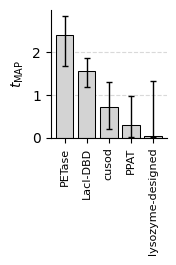

In [29]:
# -----------------------------
# Build dataframe
# -----------------------------
rows = []
for r in results:
    fname = r["file"].replace(".csv", "")
    dataset = "-".join(fname.split("_")[0:2])

    rows.append({
        "dataset": dataset,
        "t": r["tmap"]["t_map"],
        "t_lo": r["tmap"]["t_lower_confidence_interval"],
        "t_hi": r["tmap"]["t_upper_confidence_interval"],
    })

df = pd.DataFrame(rows)

# Coerce numeric + drop non-finite
for c in ["t", "t_lo", "t_hi"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["t", "t_lo", "t_hi"]).reset_index(drop=True)

# -----------------------------
# Fix CI ordering (ensure lo <= hi)
# -----------------------------
lo = np.minimum(df["t_lo"].to_numpy(), df["t_hi"].to_numpy())
hi = np.maximum(df["t_lo"].to_numpy(), df["t_hi"].to_numpy())
df["t_lo"] = lo
df["t_hi"] = hi

# -----------------------------
# Drop poorly fitted datasets (avoid div-by-zero)
# -----------------------------
# eps = 1e-300  # tiny, only to avoid division by zero
# poor_fit = ((df["t_hi"] / np.maximum(df["t_lo"], eps)) >= 10.0) & (df["t_hi"] > 1.0)
# df = df.loc[~poor_fit].reset_index(drop=True)

# -----------------------------
# Ensure t is inside [lo, hi]
# If not, you can either DROP or CLAMP. Dropping is safer/cleaner.
# -----------------------------
bad = (df["t"] < df["t_lo"]) | (df["t"] > df["t_hi"])
if bad.any():
    print("Dropping rows where t is outside [t_lo, t_hi]:")
    print(df.loc[bad, ["dataset", "t", "t_lo", "t_hi"]])
df = df.loc[~bad].reset_index(drop=True)

# -----------------------------
# Sort by t descending
# -----------------------------
df = df.sort_values("t", ascending=False).reset_index(drop=True)

# -----------------------------
# Asymmetric error bars (guaranteed non-negative now)
# -----------------------------
t = df["t"].to_numpy()
t_lo = df["t_lo"].to_numpy()
t_hi = df["t_hi"].to_numpy()
yerr = np.vstack([t - t_lo, t_hi - t])

# -----------------------------
# Plot (single bar call; x aligned with errorbar)
# -----------------------------
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(2, 2.75))

ax.bar(
    x,
    t,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.75,
    zorder=2
)

ax.errorbar(
    x=x,
    y=t,
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=2,
    zorder=3
)

step = 1  # change to 3 if you truly want every 3rd label
ax.set_xticks(x[::step])
ax.set_xticklabels(df["dataset"].iloc[::step], rotation=90, fontsize=8)

ax.set_ylabel(r"$t_{\mathrm{MAP}}$")
# ax.set_yscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", ls="--", c="0.85", zorder=1)

plt.tight_layout()
plt.savefig("../figures/figure_2/tmap_vs_sparse.pdf")
plt.show()

### Smooth example

In [73]:
df = pd.read_csv('../data_files/sparse_datasets/PETase.csv')

df = df.dropna()

# if len(df) > 4000:
#     continue

# Extract sequence objects
seqs_raw = df["sequence"].astype(str).str.strip().str.replace(".", "-", regex=False)

L = seqs_raw.str.len().max()  # target alignment length
seqs_raw = seqs_raw.str.pad(width=L, side="right", fillchar="-")

sequences = [fl.BaseNumpySequence(s) for s in seqs_raw]
fitness = df["fitness"].to_numpy()

# Scale K to sqrt of number of sequences
knn_k = max(int(np.sqrt(len(sequences))), 2)

# Construct fitness landscape
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="knn",
    k=knn_k,
    backend="auto",
    _compute_hamming_edges=False
)

/Users/matthewspence/Documents/Documents/graph-ruggedness-de/.env/lib/python3.12/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 1 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "


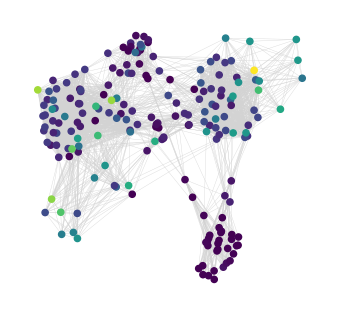

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

G = landscape.graph

edge_frac = 1.0
seed = 0  # for reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# Use a fixed layout so nodes/edges align
# (spring_layout can be slow for large graphs; if G already has positions, use those)
pos = nx.spring_layout(G, seed=seed)

fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Draw only sampled edges
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# Draw all nodes
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=20,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()
plt.tight_layout()
# plt.savefig(
#     "../figures/figure_2/MAFG_MOUSE_Tsuboyama_2023_1K1V_smooth_example.pdf",
#     bbox_inches="tight"
# )
plt.show()

### Rugged example

In [70]:
df = pd.read_csv('../data_files/sparse_datasets/lysozyme_designed.csv')

df = df.dropna()

# if len(df) > 4000:
#     continue

# Extract sequence objects
seqs_raw = df["sequence"].astype(str).str.strip().str.replace(".", "-", regex=False)

L = seqs_raw.str.len().max()  # target alignment length
seqs_raw = seqs_raw.str.pad(width=L, side="right", fillchar="-")

sequences = [fl.BaseNumpySequence(s) for s in seqs_raw]
fitness = df["fitness"].to_numpy()

# Scale K to sqrt of number of sequences
knn_k = max(int(np.sqrt(len(sequences))), 2)

# Construct fitness landscape
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="knn",
    k=knn_k,
    backend="auto",
    _compute_hamming_edges=False
)

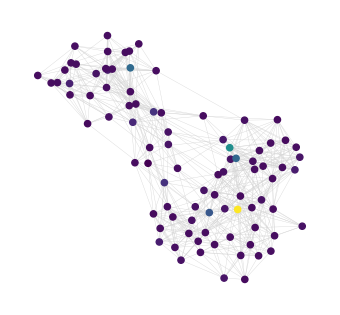

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

G = landscape.graph

edge_frac = 1.0
seed = 0  # for reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# Use a fixed layout so nodes/edges align
# (spring_layout can be slow for large graphs; if G already has positions, use those)
pos = nx.spring_layout(G, seed=seed)

fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Draw only sampled edges
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# Draw all nodes
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=20,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()
plt.tight_layout()
# plt.savefig(
#     "../figures/figure_2/MAFG_MOUSE_Tsuboyama_2023_1K1V_smooth_example.pdf",
#     bbox_inches="tight"
# )
plt.show()

In [80]:
df = pd.read_csv('../data_files/sparse_datasets/ppat.csv')

df = df.dropna()

# if len(df) > 4000:
#     continue

# Extract sequence objects
seqs_raw = df["sequence"].astype(str).str.strip().str.replace(".", "-", regex=False)

L = seqs_raw.str.len().max()  # target alignment length
seqs_raw = seqs_raw.str.pad(width=L, side="right", fillchar="-")

sequences = [fl.BaseNumpySequence(s) for s in seqs_raw]
fitness = df["fitness"].to_numpy()

# Scale K to sqrt of number of sequences
knn_k = max(int(np.sqrt(len(sequences))), 2)

# Construct fitness landscape
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="knn",
    k=knn_k,
    backend="auto",
    _compute_hamming_edges=False
)

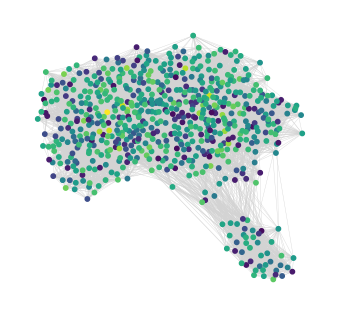

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

G = landscape.graph

edge_frac = 1.0
seed = 0  # for reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# Use a fixed layout so nodes/edges align
# (spring_layout can be slow for large graphs; if G already has positions, use those)
pos = nx.spring_layout(G, seed=seed)

fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Draw only sampled edges
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# Draw all nodes
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=10,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()
plt.tight_layout()
# plt.savefig(
#     "../figures/figure_2/MAFG_MOUSE_Tsuboyama_2023_1K1V_smooth_example.pdf",
#     bbox_inches="tight"
# )
plt.show()